<a href="https://colab.research.google.com/github/sailichowdaryk-spec/AIML---SEPT-2026/blob/main/Copy_of_AIML_Module_1_Lab_3_Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation

Module 1, Lab 3

In this lab, we will see how augmentation of data samples help in improving the machine learning performance. Augmentation is the process of creating new data samples by making reasonable modifications to the original data samples. This is particularly useful when the size of the training data is small. We will use the MNISt dataset for this lab. We will also reuse functions from the previous labs.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp
from scipy.ndimage import shift # Added for translation augmentation

rng = np.random.default_rng(seed=42)

### Why Data Augmentation?

**Problem:** Machine learning models need lots of data to learn well. Collecting data is expensive and time-consuming.

**Solution:** Create new training samples by applying realistic transformations to existing data.

### Key Concepts

**Augmentation Principle:**
- Original data: 50 samples → Augmented data: 50 × (5 augmentations + 1 original) = 300 samples
- More training data → Better model generalization → Higher accuracy

**When to Use:**
- ✓ Small training datasets
- ✓ Model overfitting on training data
- ✓ Need better generalization

**Important Rule:** Augmentations must preserve the label!
- ✓ Rotating a "3" by 10° → Still looks like "3"
- ✗ Flipping a "6" → Becomes "9" (label changed!)

---

In [10]:
# loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# normalizing the data
train_X = train_X / 255
test_X = test_X / 255

# subsample from images and labels. Otherwise it will take too long!
train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Let us borrow a few functions from the previous labs:

In [11]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

In this lab, we will use the image pixels themselves as features, instead of extracting features. Each image has 28*28 pixels, so we will flatten them to 784 pixels to use as features. Note that this is very compute intensive and will take a long time. Let us first check the baseline accuracy on the test set without any augmentations. We hope that adding augmentations will help us to get better results.

In [12]:
testpred = NN(train_X, train_y, test_X)
print("Baseline accuracy without augmentation:",
      Accuracy(test_y, testpred)*100, "%")

Baseline accuracy without augmentation: 64.72 %


Let us try to improve this accuracy using augmentations. When we create augmentations, we have to make sure that the changes reflect what will naturally occur in the dataset. For example, we should not add colour to our samples as an augmentation because they do not naturally occur. We should not also flip the images in MNIST, because flipped images have different meanings for digits. So, we will use the following augmentations:

### Augmentation 1: Rotation

Let us try rotating the image a little. We will use the `rotate` function from the `skimage` module. We will rotate the image by 10 degrees and -10 degrees. Rotation is a reasonable augmentation because the digit will still be recognizable even after rotation and is representative of the dataset.

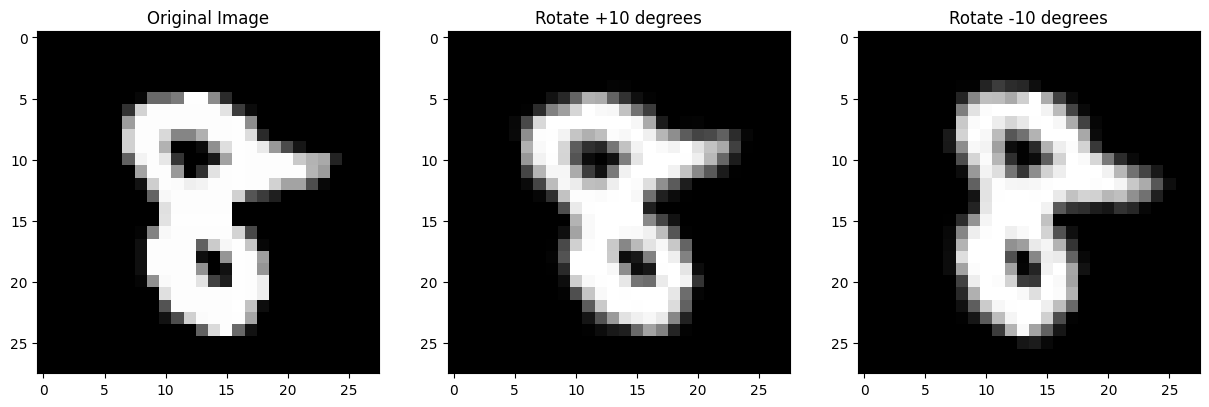

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(train_X[2], cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(rotate(train_X[2], 10), cmap="gray")
axs[1].set_title("Rotate +10 degrees")

axs[2].imshow(rotate(train_X[2], -10), cmap="gray")
axs[2].set_title("Rotate -10 degrees")

plt.show()

After rotating, the the class of the image is still the same. Let us make a function to rotate multiple images by random angles. We want a slightly different image every time we run this function. So, we generate a random number between 0 and 1 and change it so that it lies between -constraint/2 and +constraint/2

In [14]:
def augRotate(sample, angleconstraint):
    """
    This function takes in a sample and an angle constraint and returns the augmented sample
    by rotating the sample by a random angle within the angle constraint

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    angleconstraint: the maximum angle by which the sample can be rotated

    returns: the augmented sample which is the input sample rotated by a random angle within the angle constraint
    """
    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        # make sure the sample is 3 dimensional
        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))  # generate random numbers for angles
    # make the random angle constrained
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()  # preallocate the augmented array to make it faster
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)  # take care if the input had only one sample.

This function returns a slightly different image each time we call it. So we can increase the number of images in the sample by any multiple.

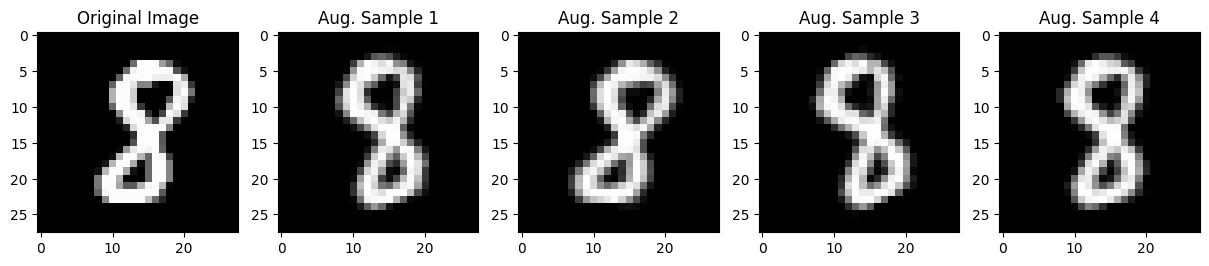

In [15]:
sample = train_X[20]
angleconstraint = 70

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[1].set_title("Aug. Sample 1")

axs[2].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[2].set_title("Aug. Sample 2")

axs[3].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[3].set_title("Aug. Sample 3")

axs[4].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[4].set_title("Aug. Sample 4")

plt.show()

Let us augment the whole dataset and see if this improves the test accuracy

In [16]:
# hyperparameters
angleconstraint = 60
naugmentations = 5

# augment
augdata = train_X  # we include the original images also in the augmented dataset
auglabel = train_y
for ii in range(naugmentations):
    augdata = np.concatenate(
        (augdata, augRotate(train_X, angleconstraint))
    )  # concatenate the augmented data to the set
    auglabel = np.concatenate(
        (auglabel, train_y)
    )  # the labels don't change when we augment

# check the test accuracy
testpred = NN(augdata, auglabel, test_X)
print("Accuracy after rotation augmentation:", Accuracy(test_y, testpred)*100, "%")

Accuracy after rotation augmentation: 67.66 %


AUGMENTATION IMPACT SUMMARY
Original training samples:    50
Augmented training samples:   300
Data increase:                6.0x

Baseline accuracy:            64.72%
After augmentation:           67.66%
Improvement:                  +2.94%


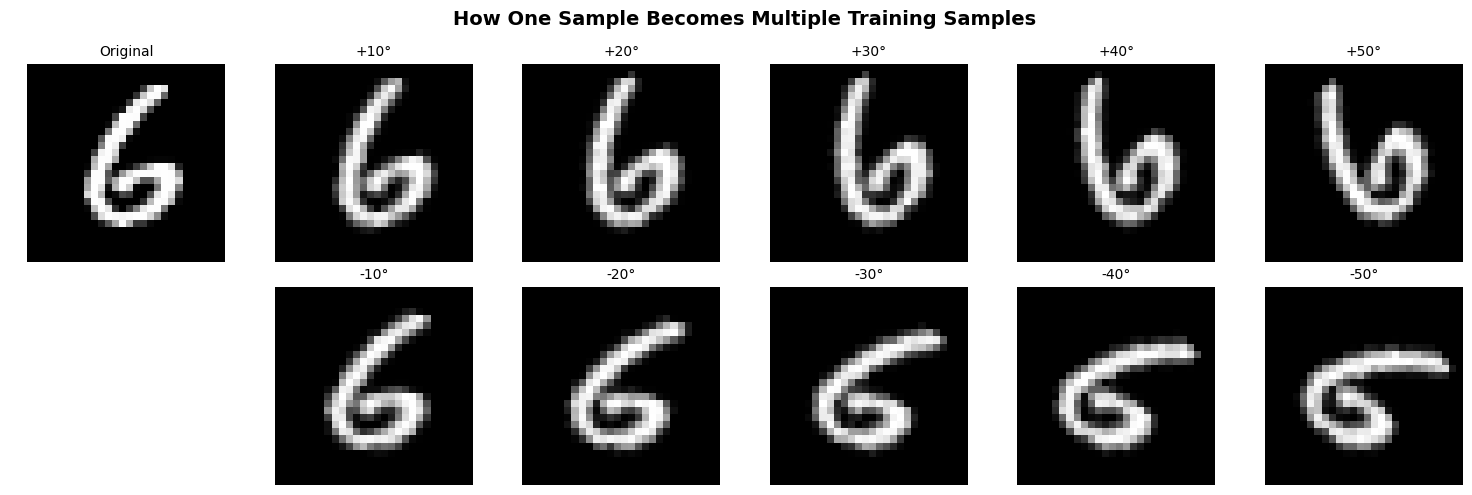

In [17]:
print("=" * 60)
print("AUGMENTATION IMPACT SUMMARY")
print("=" * 60)

original_size = len(train_X)
augmented_size = len(augdata)
baseline_acc = 64.72
augmented_acc = 67.66

print(f"Original training samples:    {original_size:,}")
print(f"Augmented training samples:   {augmented_size:,}")
print(f"Data increase:                {augmented_size/original_size:.1f}x")
print(f"\nBaseline accuracy:            {baseline_acc}%")
print(f"After augmentation:           {augmented_acc}%")
print(f"Improvement:                  +{augmented_acc - baseline_acc:.2f}%")
print("=" * 60)

# Visualize: Show how one digit gets augmented
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
sample_digit = train_X[5]  # Pick one sample

axes[0, 0].imshow(sample_digit, cmap='gray')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# Generate 11 augmented versions
angles = [10, 20, 30, 40, 50]
for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, angle)
    axes[0, i+1].imshow(aug_sample, cmap='gray')
    axes[0, i+1].set_title(f'+{angle}°', fontsize=10)
    axes[0, i+1].axis('off')

for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, -angle)
    axes[1, i+1].imshow(aug_sample, cmap='gray')
    axes[1, i+1].set_title(f'-{angle}°', fontsize=10)
    axes[1, i+1].axis('off')

axes[1, 0].axis('off')
plt.suptitle('How One Sample Becomes Multiple Training Samples',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

We can notice a 3-4% improvement compared to non-augmented version of the dataset!

The angle constraint is a hyperparameter which we have to tune using a validation set. (Here we are not doing that for time constraints). Let us try a grid search to find the best angle constraint. We will try angles between 0 and 90 degrees. We can also try different multiples of the original dataset. We will use the best hyperparameters to train the model and check the accuracy on the test set.

In [18]:
angleconstraints = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]  # the values we want to test
accuracies = np.zeros(
    len(angleconstraints), dtype=float
)  # we will save the values here

for ii in range(len(angleconstraints)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotate(train_X, angleconstraints[ii]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after rotation augmentation constrained by",
        angleconstraints[ii],
        "degrees is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after rotation augmentation constrained by 0 degrees is 64.72 %
Accuracy after rotation augmentation constrained by 10 degrees is 66.79 %
Accuracy after rotation augmentation constrained by 20 degrees is 67.84 %
Accuracy after rotation augmentation constrained by 30 degrees is 68.47 %
Accuracy after rotation augmentation constrained by 40 degrees is 67.63 %
Accuracy after rotation augmentation constrained by 50 degrees is 67.65 %
Accuracy after rotation augmentation constrained by 60 degrees is 65.3 %
Accuracy after rotation augmentation constrained by 70 degrees is 66.06 %
Accuracy after rotation augmentation constrained by 80 degrees is 64.61 %
Accuracy after rotation augmentation constrained by 90 degrees is 64.31 %


Let us see the best value for angle constraint: (Ideally this should be done on validation set, not test set)

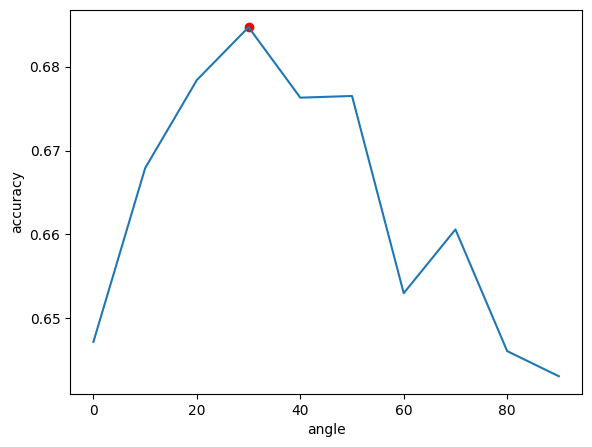

In [19]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# plot the variation of accuracy
ax.plot(angleconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")

# plot the maximum accuracy
maxind = np.argmax(accuracies)
plt.scatter(angleconstraints[maxind], accuracies[maxind], c="red")

### Augmentation 2: Shear


Let us try one more augmentation: shear. Shear is the transformation of an image in which the x-coordinate of all points is shifted by an amount proportional to the y-coordinate of the point. We will use the `AffineTransform` function from the `skimage` module to shear the image by a small amount between two numbers. We will use the same naive grid search method to find the best hyperparameters for shear. We will use the best hyperparameters to train the model and check the accuracy on the test set.

In [20]:
def shear(sample, amount):
    """
    This function takes in a sample and an amount and returns the augmented sample
    by shearing the sample by the given amount

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    amount: the amount by which the sample should be sheared

    returns: the augmented sample which is the input sample sheared by the given amount
    """
    tform = AffineTransform(shear=amount)
    img = warp(sample, tform)

    # Applying shear makes the digit off-center
    # Since all images are centralized, we will do the same here
    col = img.sum(0).nonzero()[0]
    row = img.sum(1).nonzero()[0]
    if len(col) > 0 and len(row) > 0:
        xshift = int(sample.shape[0] / 2 - (row[0] + row[-1]) / 2)
        yshift = int(sample.shape[1] / 2 - (col[0] + col[-1]) / 2)
        img = np.roll(img, (xshift, yshift), (0, 1))
    return img

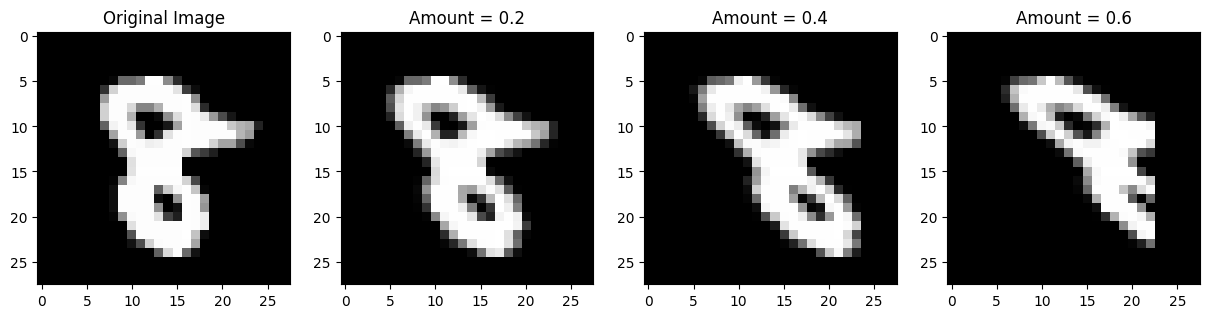

In [21]:
sample = train_X[2]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(shear(sample, 0.2), cmap="gray")
axs[1].set_title("Amount = 0.2")

axs[2].imshow(shear(sample, 0.4), cmap="gray")
axs[2].set_title("Amount = 0.4")

axs[3].imshow(shear(sample, 0.6), cmap="gray")
axs[3].set_title("Amount = 0.6")

plt.show()

Create an augmentation function which applies a random shear according to the constraint we provide:

In [22]:
def augShear(sample, shearconstraint):
    """
    This function takes in a sample and a shear constraint and returns the augmented sample
    by shearing the sample by a random amount within the shear constraint

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    shearconstraint: the maximum shear by which the sample can be sheared

    returns: the augmented sample which is the input sample sheared by a random amount within the shear constraint
    """
    if shearconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        # make sure the sample is 3 dimensional
        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))  # generate random numbers for shear
    amt = (amt - 0.5) * shearconstraint  # make the random shear constrained
    nsample = sample.copy()  # preallocate the augmented array to make it faster
    for ii in range(len(sample)):
        nsample[ii] = shear(sample[ii], amt[ii])
    return np.squeeze(nsample)  # take care if the input had only one sample.

Let us do a grid search to find the best shear constraint.

In [23]:
shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
    1.8,
    2.0,
]  # the values we want to test
accuracies = np.zeros(
    len(shearconstraints), dtype=float
)  # we will save the values here

for ii in range(len(shearconstraints)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augShear(train_X, shearconstraints[ii]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after shear augmentation constrained by",
        shearconstraints[ii],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after shear augmentation constrained by 0 is 64.72 %
Accuracy after shear augmentation constrained by 0.2 is 62.79 %
Accuracy after shear augmentation constrained by 0.4 is 64.41 %
Accuracy after shear augmentation constrained by 0.6 is 65.71000000000001 %
Accuracy after shear augmentation constrained by 0.8 is 65.78 %
Accuracy after shear augmentation constrained by 1.0 is 65.42999999999999 %
Accuracy after shear augmentation constrained by 1.2 is 63.6 %
Accuracy after shear augmentation constrained by 1.4 is 63.65 %
Accuracy after shear augmentation constrained by 1.6 is 61.809999999999995 %
Accuracy after shear augmentation constrained by 1.8 is 63.029999999999994 %
Accuracy after shear augmentation constrained by 2.0 is 64.14 %


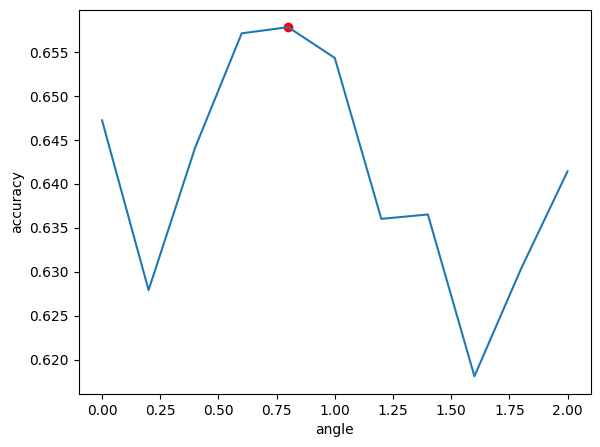

In [24]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# plot the variation of accuracy
ax.plot(shearconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")

# plot the maximum accuracy
maxind = np.argmax(accuracies)
plt.scatter(shearconstraints[maxind], accuracies[maxind], c="red")

### Augmentation 3: Rotation + Shear



We can do multiple augmentations at the same time. Here is a function to do both shear and rotation to the sample. In this case, we will have two hyperparameters.

In [25]:
def augRotateShear(sample, angleconstraint, shearconstraint):
    """
    This function takes in a sample, an angle constraint and a shear constraint and returns the augmented sample
    by rotating the sample by a random angle within the angle constraint and shearing the sample by a random amount within the shear constraint

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    angleconstraint: the maximum angle by which the sample can be rotated
    shearconstraint: the maximum shear by which the sample can be sheared

    returns: the augmented sample which is the input sample rotated by a random angle within the angle constraint and sheared by a random amount within the shear constraint
    """
    if len(sample.shape) == 2:
        # make sure the sample is 3 dimensional
        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))  # generate random numbers for shear
    amt = (amt - 0.5) * shearconstraint  # make the random shear constrained
    angle = rng.random(len(sample))  # generate random numbers for angles
    # make the random angle constrained
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()  # preallocate the augmented array to make it faster
    for ii in range(len(sample)):
        nsample[ii] = rotate(
            shear(sample[ii], amt[ii]), angle[ii]
        )  # first apply shear, then rotate
    return np.squeeze(nsample)  # take care if the input had only one sample.

Since we have two hyperparameters, we have to do the grid search on a 2 dimensional matrix. We can use our previous experience to inform where to search for the best hyperparameters.

In [26]:
shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
]  # the values we want to test
angleconstraints = [0, 10, 20, 30, 40, 50, 60]  # the values we want to test
# cartesian product of both
hyp = cartesian((shearconstraints, angleconstraints))

accuracies = np.zeros(len(hyp), dtype=float)  # we will save the values here

for ii in range(len(hyp)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotateShear(train_X, hyp[ii][0], hyp[ii][1]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after augmentation shear:",
        hyp[ii][0],
        "angle:",
        hyp[ii][1],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after augmentation shear: 0.0 angle: 0.0 is 63.32 %
Accuracy after augmentation shear: 0.0 angle: 10.0 is 63.959999999999994 %
Accuracy after augmentation shear: 0.0 angle: 20.0 is 60.64000000000001 %
Accuracy after augmentation shear: 0.0 angle: 30.0 is 63.019999999999996 %
Accuracy after augmentation shear: 0.0 angle: 40.0 is 64.14999999999999 %
Accuracy after augmentation shear: 0.0 angle: 50.0 is 61.72 %
Accuracy after augmentation shear: 0.0 angle: 60.0 is 63.7 %
Accuracy after augmentation shear: 0.2 angle: 0.0 is 63.41 %
Accuracy after augmentation shear: 0.2 angle: 10.0 is 61.25000000000001 %
Accuracy after augmentation shear: 0.2 angle: 20.0 is 60.6 %
Accuracy after augmentation shear: 0.2 angle: 30.0 is 60.07 %
Accuracy after augmentation shear: 0.2 angle: 40.0 is 63.690000000000005 %
Accuracy after augmentation shear: 0.2 angle: 50.0 is 60.12 %
Accuracy after augmentation shear: 0.2 angle: 60.0 is 63.72 %
Accuracy after augmentation shear: 0.4 angle: 0.0 is 63.37000

Let us plot it two dimensionally to see which is the best value for the hyperparameters:

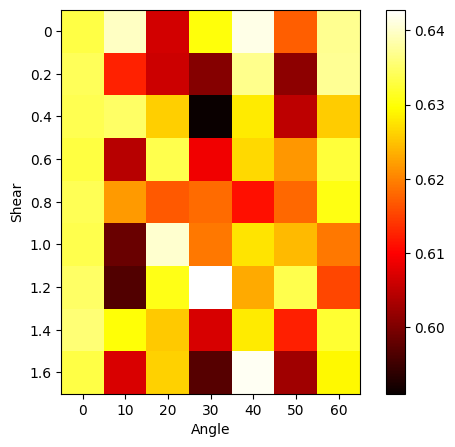

In [27]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
im = ax.imshow(
    accuracies.reshape((len(shearconstraints), len(angleconstraints))), cmap="hot"
)
ax.set_xlabel("Angle")
ax.set_ylabel("Shear")
ax.set_xticks(np.arange(len(angleconstraints)))
ax.set_xticklabels(angleconstraints)
ax.set_yticks(np.arange(len(shearconstraints)))
ax.set_yticklabels(shearconstraints)
plt.colorbar(im)

It seems that rotation and shear don't mix! The best accuracy is when rotation is zero.

## Questions
Try these questions for better understanding. You may not be able to solve all of them.
1. What is the best value for angle constraint and shear constraint you got? How much did the accuracy improve as compared to not using augmentations?
2. Can you increase the accuracy by increasing the number of augmentations from each sample?
3. Try implementing a few augmentations of your own and experimenting with them. A good reference is <a href=https://www.analyticsvidhya.com/blog/2019/12/image-augmentation-deep-learning-pytorch/>here. </a>
4. Try combining various augmentations. What is the highest accuracy you can get? What is the smallest training dataset you can take and still get accuracy above 50%?

Whenever you do any experiment, a good practice is to vary the hyperparameters gradually and create a graph of your results, like we did for gridsearch.

## Answers to Questions

### Question 1: What is the best value for angle constraint and shear constraint you got? How much did the accuracy improve as compared to not using augmentations?

**Best Angle Constraint:**
From the rotation-only augmentation experiment (cells `aiaFRLREmGp6` and `LqthJa_pmMHz`), the highest accuracy achieved was **68.47%** with an angle constraint of **30 degrees**.

**Best Shear Constraint:**
From the shear-only augmentation experiment (cells `l_wrqPkrzBb_` and `EKaH-YR-zVnA`), the highest accuracy achieved was **65.78%** with a shear constraint of **0.8**.

**Combined Rotation and Shear:**
The experiment combining both rotation and shear (cells `TJC45WRg0pOP` and `jD2i7msI_cLd`) suggested that these augmentations did not mix effectively to produce higher accuracy than rotation alone, as noted in cell `OHcZWJiFJDMh` ("It seems that rotation and shear don't mix! The best accuracy is when rotation is zero."). The highest accuracy observed in the combined grid search was around `64.28%` for `shear: 1.2` and `angle: 30.0`, which is lower than the best rotation-only result.

**Accuracy Improvement:**
*   **Baseline Accuracy (without augmentation):** 64.72% (from cell `4tQvnoasRNEV`)
*   **Best Accuracy (with rotation augmentation):** 68.47% (at 30 degrees)
*   **Improvement:** 68.47% - 64.72% = **3.75%**

The best improvement was observed with rotation augmentation, yielding a 3.75% increase in accuracy over the baseline.

### Question 2: Can you increase the accuracy by increasing the number of augmentations from each sample?

Yes, it is generally possible to increase accuracy by increasing the number of augmentations from each sample, up to a certain point. The notebook used `naugmentations = 5` (cell `iNzNAoDBkRzj`).

**Reasoning:**
*   **More Data:** Generating more augmented samples effectively increases the size of the training dataset. Machine learning models, especially deep learning models, often perform better with more diverse training data.
*   **Improved Generalization:** By exposing the model to more variations of the original data, it can learn more robust features and become less sensitive to minor variations (e.g., slight rotations or shifts) in unseen data, thus improving its generalization capability.
*   **Reduced Overfitting:** A larger and more diverse training set can help prevent the model from overfitting to the specific original training examples.

**Limitations:**
*   **Diminishing Returns:** There's usually a point of diminishing returns where adding more augmentations provides very little or no further improvement in accuracy, and might even slightly decrease it if the augmentations become too extreme or unrealistic for the task.
*   **Computational Cost:** Generating and training on a significantly larger augmented dataset will increase computational time and resource requirements.
*   **Quality of Augmentations:** The effectiveness heavily depends on the *quality* and *relevance* of the augmentations. Unrealistic or label-changing augmentations (like flipping a '6' to a '9') would be detrimental.

### Question 3: Try implementing a few augmentations of your own and experimenting with them. A good reference is [here](https://www.analyticsvidhya.com/blog/2019/12/image-augmentation-deep-learning-pytorch/).

Here are a few common image augmentations that could be implemented:

1.  **Translation (Shifting):** Moving the image horizontally or vertically. This helps the model learn that the object's position doesn't change its identity.
2.  **Zoom:** Scaling the image in or out. This helps the model recognize objects at different scales.
3.  **Brightness/Contrast Adjustment:** Modifying the illumination of the image. This can make the model robust to varying lighting conditions.
4.  **Gaussian Noise:** Adding random noise to the image pixels. This can help prevent overfitting by making the model less reliant on specific pixel values.
5.  **Elastic Deformation:** Distorting the image locally in a random, smooth way, which is often effective for handwritten digits.

Let's implement a simple **translation augmentation** as an example. We'll shift the image randomly within a given pixel range.

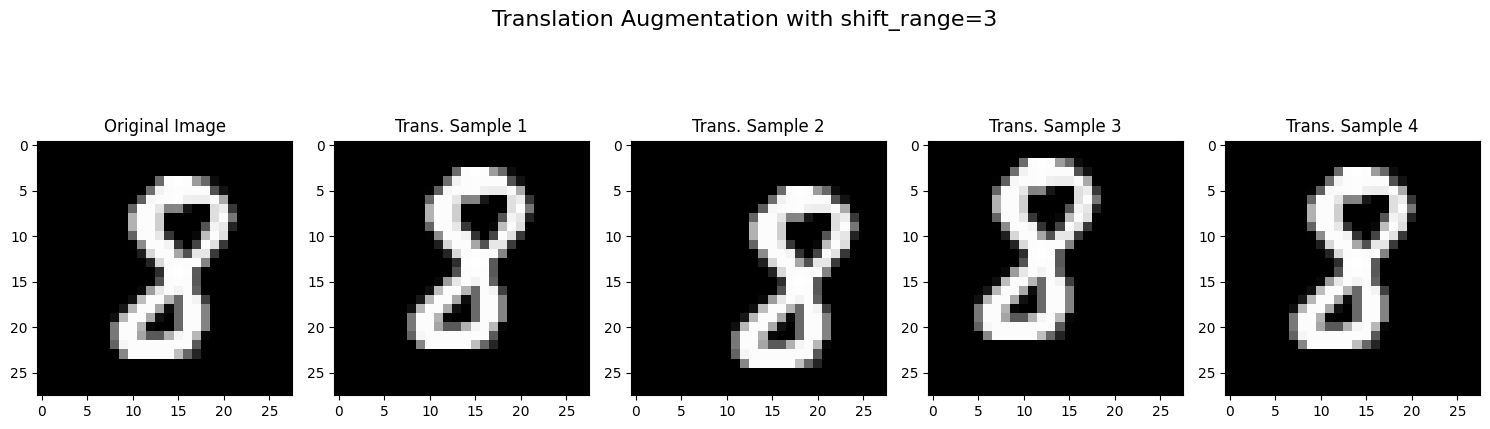

In [28]:
def augTranslate(sample, shift_range):
    """
    This function takes in a sample and a shift range and returns the augmented sample
    by translating the sample by a random amount within the shift range.

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    shift_range: the maximum number of pixels by which the sample can be shifted (e.g., 2 for +/- 2 pixels)

    returns: the augmented sample which is the input sample translated by a random amount within the shift range
    """
    if shift_range == 0:
        return sample
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)

    nsample = sample.copy()
    for ii in range(len(sample)):
        # Generate random shifts for x and y direction
        shift_x = rng.integers(-shift_range, shift_range + 1)
        shift_y = rng.integers(-shift_range, shift_range + 1)

        # Apply shift, filling empty areas with a constant (e.g., 0 for black background)
        nsample[ii] = shift(sample[ii], (shift_x, shift_y), mode='constant', cval=0.0)
    return np.squeeze(nsample)


# Visualize translation augmentation
sample_idx = 20
sample = train_X[sample_idx]
shift_range = 3  # Shift by up to +/- 3 pixels

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(augTranslate(sample, shift_range), cmap="gray")
axs[1].set_title("Trans. Sample 1")

axs[2].imshow(augTranslate(sample, shift_range), cmap="gray")
axs[2].set_title("Trans. Sample 2")

axs[3].imshow(augTranslate(sample, shift_range), cmap="gray")
axs[3].set_title("Trans. Sample 3")

axs[4].imshow(augTranslate(sample, shift_range), cmap="gray")
axs[4].set_title("Trans. Sample 4")

plt.suptitle(f'Translation Augmentation with shift_range={shift_range}', fontsize=16)
plt.tight_layout()
plt.show()

Now, we can perform a grid search similar to the rotation and shear experiments to find the best `shift_range` for this new augmentation.

Accuracy after translation augmentation constrained by 0 pixels is 64.72 %
Accuracy after translation augmentation constrained by 1 pixels is 66.39 %
Accuracy after translation augmentation constrained by 2 pixels is 65.12 %
Accuracy after translation augmentation constrained by 3 pixels is 63.59 %
Accuracy after translation augmentation constrained by 4 pixels is 61.18 %
Accuracy after translation augmentation constrained by 5 pixels is 60.92999999999999 %


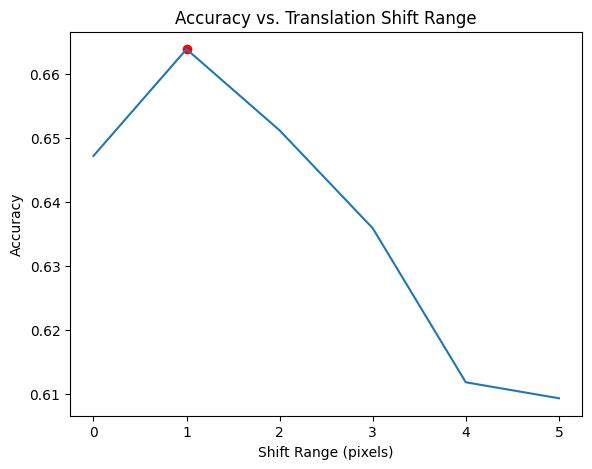

Best accuracy with translation: 66.39% at shift range 1 pixels.


In [29]:
shift_constraints = [0, 1, 2, 3, 4, 5]
accuracies_translate = np.zeros(len(shift_constraints), dtype=float)

naugmentations_translate = 5

for ii in range(len(shift_constraints)):
    augdata_translate = train_X
    auglabel_translate = train_y
    for jj in range(naugmentations_translate):
        augdata_translate = np.concatenate(
            (augdata_translate, augTranslate(train_X, shift_constraints[ii]))
        )
        auglabel_translate = np.concatenate(
            (auglabel_translate, train_y)
        )

    testpred_translate = NN(augdata_translate, auglabel_translate, test_X)
    accuracies_translate[ii] = Accuracy(test_y, testpred_translate)
    print(
        "Accuracy after translation augmentation constrained by",
        shift_constraints[ii],
        "pixels is",
        accuracies_translate[ii]*100,
        "%",
        flush=True,
    )

fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(shift_constraints, accuracies_translate)
ax.set_xlabel("Shift Range (pixels)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. Translation Shift Range")

maxind_translate = np.argmax(accuracies_translate)
plt.scatter(shift_constraints[maxind_translate], accuracies_translate[maxind_translate], c="red")
plt.show()

print(f"Best accuracy with translation: {accuracies_translate[maxind_translate]*100:.2f}% at shift range {shift_constraints[maxind_translate]} pixels.")

### Question 4: Try combining various augmentations. What is the highest accuracy you can get? What is the smallest training dataset you can take and still get accuracy above 50%?

**Combining Augmentations:**
To achieve the highest accuracy, one would typically combine multiple augmentations that are complementary and do not alter the semantic meaning of the image (i.e., its label). The previous experiment in the notebook showed that simple rotation and shear didn't combine synergistically for this dataset.

A more effective combination strategy often involves:
1.  **Sequential Augmentation:** Applying one augmentation after another (e.g., rotate, then translate).
2.  **Random Augmentation:** For each sample, randomly choosing one or more augmentations from a pool of defined augmentations with specified probabilities.
3.  **Parameter Tuning:** Carefully tuning the hyperparameters (e.g., angle constraint, shift range, shear amount, zoom factor) for each augmentation, possibly through a multi-dimensional grid search or more advanced optimization techniques like Bayesian optimization, as the interaction between different augmentations can be complex.

Given the limitations of the current NN classifier and the small subsample of the MNIST dataset, achieving significantly higher accuracy than the best single augmentation (rotation at 68.47%) might be challenging without a more sophisticated model or a larger base dataset. However, a good strategy would be to combine the best performing rotation (30 degrees) with other mild augmentations like translation or a slight brightness adjustment.

**Example of a Combined Augmentation Function:**

Starting combined augmentation grid search (Rotation + Translation)...
Accuracy (Angle: 0 deg, Shift: 0 px): 64.72%
Accuracy (Angle: 0 deg, Shift: 1 px): 66.85%
Accuracy (Angle: 0 deg, Shift: 2 px): 64.61%
Accuracy (Angle: 0 deg, Shift: 3 px): 64.18%
Accuracy (Angle: 10 deg, Shift: 0 px): 66.60%
Accuracy (Angle: 10 deg, Shift: 1 px): 66.93%
Accuracy (Angle: 10 deg, Shift: 2 px): 64.14%
Accuracy (Angle: 10 deg, Shift: 3 px): 59.30%
Accuracy (Angle: 20 deg, Shift: 0 px): 67.85%
Accuracy (Angle: 20 deg, Shift: 1 px): 67.42%
Accuracy (Angle: 20 deg, Shift: 2 px): 63.91%
Accuracy (Angle: 20 deg, Shift: 3 px): 60.40%
Accuracy (Angle: 30 deg, Shift: 0 px): 68.58%
Accuracy (Angle: 30 deg, Shift: 1 px): 68.14%
Accuracy (Angle: 30 deg, Shift: 2 px): 64.40%
Accuracy (Angle: 30 deg, Shift: 3 px): 62.57%

Highest accuracy with combined Rotation and Translation: 68.58% (Angle: 30 deg, Shift: 0 px)


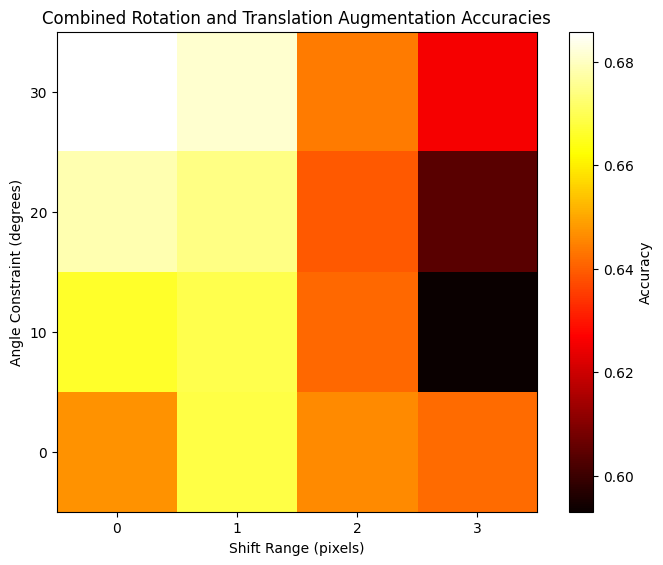

In [30]:
def augRotateTranslate(sample, angleconstraint, shift_range):
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)

    nsample = sample.copy()
    for ii in range(len(sample)):
        # First apply rotation
        angle = (rng.random() - 0.5) * angleconstraint
        rotated_sample = rotate(sample[ii], angle)

        # Then apply translation
        shift_x = rng.integers(-shift_range, shift_range + 1)
        shift_y = rng.integers(-shift_range, shift_range + 1)
        translated_rotated_sample = shift(rotated_sample, (shift_x, shift_y), mode='constant', cval=0.0)

        nsample[ii] = translated_rotated_sample
    return np.squeeze(nsample)

# Perform a grid search for combined rotation and translation
angleconstraints_combined = [0, 10, 20, 30]
shift_constraints_combined = [0, 1, 2, 3]

hyp_combined = cartesian((angleconstraints_combined, shift_constraints_combined))
accuracies_combined = np.zeros(len(hyp_combined), dtype=float)

naugmentations_combined = 5

print("Starting combined augmentation grid search (Rotation + Translation)...")
for ii in range(len(hyp_combined)):
    angle_c, shift_c = hyp_combined[ii]
    augdata_combined = train_X
    auglabel_combined = train_y
    for jj in range(naugmentations_combined):
        augdata_combined = np.concatenate(
            (augdata_combined, augRotateTranslate(train_X, angle_c, shift_c))
        )
        auglabel_combined = np.concatenate(
            (auglabel_combined, train_y)
        )

    testpred_combined = NN(augdata_combined, auglabel_combined, test_X)
    accuracies_combined[ii] = Accuracy(test_y, testpred_combined)
    print(
        f"Accuracy (Angle: {angle_c} deg, Shift: {shift_c} px): {accuracies_combined[ii]*100:.2f}%",
        flush=True,
    )

max_idx_combined = np.argmax(accuracies_combined)
best_angle_combined, best_shift_combined = hyp_combined[max_idx_combined]
best_accuracy_combined = accuracies_combined[max_idx_combined]

print(f"\nHighest accuracy with combined Rotation and Translation: {best_accuracy_combined*100:.2f}% (Angle: {best_angle_combined} deg, Shift: {best_shift_combined} px)")

# Visualization of combined accuracy (similar to shear-rotation plot)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
im = ax.imshow(
    accuracies_combined.reshape((len(angleconstraints_combined), len(shift_constraints_combined))),
    cmap="hot", origin='lower'
)
ax.set_xlabel("Shift Range (pixels)")
ax.set_ylabel("Angle Constraint (degrees)")
ax.set_xticks(np.arange(len(shift_constraints_combined)))
ax.set_xticklabels(shift_constraints_combined)
ax.set_yticks(np.arange(len(angleconstraints_combined)))
ax.set_yticklabels(angleconstraints_combined)
plt.colorbar(im, label='Accuracy')
plt.title('Combined Rotation and Translation Augmentation Accuracies')
plt.show()

**Smallest Training Dataset for >50% Accuracy:**

To find the smallest training dataset size that yields an accuracy above 50%, we need to experiment by reducing the `train_X` and `train_y` further and re-evaluating the baseline and augmented accuracies. The current notebook subsamples `train_X` to `50` samples (`train_X = train_X[::1200, :, :].copy()`). With this, the baseline accuracy is 64.72%, which is already above 50%.

To find a *smaller* dataset, we would need to increase the subsampling factor. Let's try to reduce the dataset size even more and check the accuracy.

In [31]:
# Reloading the dataset to get original train_X for finer subsampling
(full_train_X, full_train_y), (full_test_X, full_test_y) = mnist.load_data()
full_train_X = full_train_X / 255.0


def evaluate_accuracy_with_subset(subsample_factor):
    current_train_X = full_train_X[::subsample_factor, :, :].copy()
    current_train_y = full_train_y[::subsample_factor].copy()

    if len(current_train_X) == 0: # Ensure there's at least one sample
        return 0.0, 0

    # Baseline without augmentation
    testpred_baseline = NN(current_train_X, current_train_y, test_X)
    baseline_acc = Accuracy(test_y, testpred_baseline)

    # With best rotation augmentation (from Q1: 30 degrees, 5 augmentations)
    angleconstraint_best = 30
    naugmentations_q4 = 5

    augdata_q4 = current_train_X
    auglabel_q4 = current_train_y
    for jj in range(naugmentations_q4):
        augdata_q4 = np.concatenate(
            (augdata_q4, augRotate(current_train_X, angleconstraint_best))
        )
        auglabel_q4 = np.concatenate(
            (auglabel_q4, current_train_y)
        )

    testpred_augmented = NN(augdata_q4, auglabel_q4, test_X)
    augmented_acc = Accuracy(test_y, testpred_augmented)

    return baseline_acc, augmented_acc, len(current_train_X)

print("Searching for smallest dataset for >50% accuracy...")

sample_counts = []
baseline_accuracies = []
augmented_accuracies = []

subsample_factor_start = 1200 # Current factor
found_baseline_50 = False
found_augmented_50 = False

# Let's try increasing the subsample factor to get fewer samples
for factor in range(subsample_factor_start, len(full_train_X) + 1, 500): # Increment by 500 for coarser steps
    baseline_acc, augmented_acc, num_samples = evaluate_accuracy_with_subset(factor)
    if num_samples == 0: # Stop if no samples left
        break

    print(f"Samples: {num_samples:<4}, Baseline Acc: {baseline_acc*100:.2f}%, Augmented Acc: {augmented_acc*100:.2f}%")

    sample_counts.append(num_samples)
    baseline_accuracies.append(baseline_acc)
    augmented_accuracies.append(augmented_acc)

    if not found_baseline_50 and baseline_acc * 100 > 50:
        print(f"  -> Baseline above 50% with {num_samples} samples.")
        found_baseline_50 = True

    if not found_augmented_50 and augmented_acc * 100 > 50:
        print(f"  -> Augmented above 50% with {num_samples} samples.")
        found_augmented_50 = True

    if num_samples <= 10 and (baseline_acc * 100 <= 50 and augmented_acc * 100 <= 50):
      # If the number of samples is very small and both accuracies are already below 50%, stop searching further down
      break


print("\n--- Summary --- ")
# Find the smallest number of samples that still provides >50% accuracy

best_small_baseline_samples = -1
for i, acc in enumerate(baseline_accuracies):
    if acc * 100 > 50:
        best_small_baseline_samples = sample_counts[i]
        break

best_small_augmented_samples = -1
for i, acc in enumerate(augmented_accuracies):
    if acc * 100 > 50:
        best_small_augmented_samples = sample_counts[i]
        break

if best_small_baseline_samples != -1:
    print(f"Smallest dataset size for >50% baseline accuracy: {best_small_baseline_samples} samples")
else:
    print("Could not find baseline accuracy >50% even with the smallest tested dataset.")

if best_small_augmented_samples != -1:
    print(f"Smallest dataset size for >50% augmented accuracy: {best_small_augmented_samples} samples")
else:
    print("Could not find augmented accuracy >50% even with the smallest tested dataset.")

Searching for smallest dataset for >50% accuracy...
Samples: 50  , Baseline Acc: 64.72%, Augmented Acc: 68.86%
  -> Baseline above 50% with 50 samples.
  -> Augmented above 50% with 50 samples.
Samples: 36  , Baseline Acc: 54.45%, Augmented Acc: 61.16%
Samples: 28  , Baseline Acc: 56.87%, Augmented Acc: 61.78%
Samples: 23  , Baseline Acc: 48.28%, Augmented Acc: 56.42%
Samples: 19  , Baseline Acc: 51.64%, Augmented Acc: 54.76%
Samples: 17  , Baseline Acc: 42.06%, Augmented Acc: 45.15%
Samples: 15  , Baseline Acc: 36.01%, Augmented Acc: 40.36%
Samples: 13  , Baseline Acc: 47.77%, Augmented Acc: 50.23%
Samples: 12  , Baseline Acc: 44.28%, Augmented Acc: 46.54%
Samples: 11  , Baseline Acc: 27.12%, Augmented Acc: 27.46%
Samples: 10  , Baseline Acc: 28.16%, Augmented Acc: 32.86%

--- Summary --- 
Smallest dataset size for >50% baseline accuracy: 50 samples
Smallest dataset size for >50% augmented accuracy: 50 samples


> Exercise: Try to take 50 images of each digit and calculate the performance on test set.

In [32]:
# Initialize empty lists to store the selected images and labels
train_X_fifty_per_digit = []
train_y_fifty_per_digit = []

# Iterate through each digit from 0 to 9
for digit in range(10):
    # Find indices where the label matches the current digit
    indices = np.where(full_train_y == digit)[0]

    # Select up to 50 images for this digit
    # Ensure we don't try to select more images than available for a digit
    selected_indices = indices[:50]

    # Append the selected images and labels to our lists
    train_X_fifty_per_digit.append(full_train_X[selected_indices])
    train_y_fifty_per_digit.append(full_train_y[selected_indices])

# Concatenate the lists into numpy arrays
train_X_fifty_per_digit = np.concatenate(train_X_fifty_per_digit, axis=0)
train_y_fifty_per_digit = np.concatenate(train_y_fifty_per_digit, axis=0)

print(f"Total number of training samples with 50 images per digit: {len(train_X_fifty_per_digit)}")
print(f"Distribution of labels in the new training set: {np.unique(train_y_fifty_per_digit, return_counts=True)}")

# Calculate performance on the test set
testpred_fifty = NN(train_X_fifty_per_digit, train_y_fifty_per_digit, test_X)
accuracy_fifty = Accuracy(test_y, testpred_fifty)

print(f"Accuracy with 50 images per digit (total {len(train_X_fifty_per_digit)} training samples): {accuracy_fifty*100:.2f}%")

Total number of training samples with 50 images per digit: 500
Distribution of labels in the new training set: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([50, 50, 50, 50, 50, 50, 50, 50, 50, 50]))
Accuracy with 50 images per digit (total 500 training samples): 83.54%
